# Facial Expression Recognition System - V2
**Author:** Syed Taha Ali

An exploration of **polynomial feature expansion in fully-connected networks** applied to facial expression classification. Each neuron computes `net = W @ (x + x²)` — a quadratic activation that combines linear and squared input terms under a shared weight. The FC-only architecture deliberately excludes convolutional layers, isolating the contribution of the quadratic formula from spatial inductive bias.

**Task:** Classify 48×48 grayscale face images into 6 emotion classes: **Angry, Fear, Happy, Neutral, Sad, Surprise**.

**Version 2 improvements over V1 (36.2% → target 42–50% test accuracy):**
1. Input domain [−1,1] → [0,1]: makes `x + x²` monotone, removes pre-activation asymmetry
2. GA eval epochs 15 → 25: allows deeper networks to show their fitness advantage
3. 5-gene GA search space: adds `dropout_rate` gene, removes unstable lr=0.1 & tiny hidden=64
4. Augmentation restricted to HFlip only: rotation/affine removed (FC nets have no spatial invariance; position shift = different 2304-dim input)
5. CosineAnnealingLR replaces StepLR: smooth LR decay, no abrupt halving discontinuities
6. Final training 50 → 100 epochs: model was still improving at epoch 50
7. Kaiming init replaces Xavier: better variance preservation for 3–5 layer networks

---
## Notebook Structure
- **Section 0** - Imports & Configuration
- **Section 1** - Pre-Processing (CLAHE + Augmentation)
- **Section 2** - Custom Neural Network Architecture
- **Section 3** - Training Infrastructure
- **Section 4** - Genetic Algorithm Hyperparameter Search
- **Section 5** - Final Training & Evaluation
- **Section 6** - Cross-Validation Assessment
- **Section 7** - Inference Module & Demo
- **Section 8** - V1 vs V2 Comparison

---
## Section 0 - Imports & Configuration

In [1]:
import os
import random
import json
import copy
import numpy as np
import cv2
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from PIL import Image

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset, Subset
from torchvision import transforms, datasets

from sklearn.metrics import (
    classification_report, confusion_matrix,
    accuracy_score, ConfusionMatrixDisplay
)
from sklearn.model_selection import StratifiedKFold

print(f'PyTorch version: {torch.__version__}')
print(f'OpenCV version:  {cv2.__version__}')

PyTorch version: 2.6.0+cu124
OpenCV version:  4.13.0


In [2]:
# ─── Central configuration ───────────────────────────────────────────────────
CONFIG = {
    'data_root':  os.path.join(os.getcwd(), 'Data'),
    'classes':    ['Angry', 'Fear', 'Happy', 'Neutral', 'Sad', 'Surprise'],
    'img_size':   48,
    'seed':       42,
    'device':     'cuda' if torch.cuda.is_available() else 'cpu',
    'checkpoint_dir':  os.path.join(os.getcwd(), 'checkpoints'),
    'results_dir':     os.path.join(os.getcwd(), 'results'),
    'checkpoint_name': 'best_model_v2.pth',   # V2: separate checkpoint, does not overwrite V1
    'version':         'V2',
}

def set_seed(seed: int) -> None:
    """Fix all random seeds for reproducibility."""
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(CONFIG['seed'])

os.makedirs(CONFIG['checkpoint_dir'], exist_ok=True)
os.makedirs(CONFIG['results_dir'],    exist_ok=True)

print(f"Device           : {CONFIG['device']}")
print(f"Data             : {CONFIG['data_root']}")
print(f"Classes          : {CONFIG['classes']}")
print(f"Checkpoint name  : {CONFIG['checkpoint_name']}")
print(f"Version          : {CONFIG['version']}")

Device           : cuda
Data             : c:\Users\USER\Documents\AI_CW2\Data
Classes          : ['Angry', 'Fear', 'Happy', 'Neutral', 'Sad', 'Surprise']
Checkpoint name  : best_model_v2.pth
Version          : V2


---
## Section 1 - Pre-Processing

### 1.1 CLAHE Pre-processor (V2 - enhanced pipeline)

**Contrast Limited Adaptive Histogram Equalization (CLAHE)** is applied as the primary image enhancement step. Unlike global histogram equalisation, CLAHE divides the image into small tiles and equalises each tile independently with a contrast limit to suppress noise amplification.

**V2 CLAHE pipeline: Denoise → CLAHE → Sharpen**

Three-stage per-image processing chain, each step justified for 48×48 FER images:

| Stage | Operation | Rationale |
|-------|-----------|-----------|
| 1. Pre-denoise | `GaussianBlur(3×3)` | Removes sensor/JPEG noise *before* CLAHE; without this, CLAHE amplifies noise in low-contrast regions alongside genuine texture |
| 2. CLAHE | `clip_limit=3.0, tile=(6,6)` | **clip=3.0** (was 2.0): allows stronger local enhancement in shadow regions. **tile=(6,6)** → 8×8px tiles (was (8,8) → 6×6px); 8px tiles better match the scale of expression features (eye corners ≈10px, mouth corners ≈15px in a 48px face) |
| 3. Post-sharpen | Unsharp mask | Re-sharpens edges softened by Gaussian blur; enhances expression micro-features (wrinkles, lip contours) that differentiate e.g. sad from neutral |

**Why this matters with `W @ (x + x²)`:** The network has no convolutional spatial priors - it processes 2304 raw pixel values. It cannot learn to detect edges itself. Sharper, locally-normalised input *is* the feature extraction stage for this architecture.

### 1.2 V2 Input Domain: [0, 1]

V1 normalised to `[-1, 1]` via `Normalize([0.5], [0.5])`. V2 keeps pixels in `[0, 1]` (output of `transforms.ToTensor()`).

**Why this matters for `net = W @ (x + x²)`:**

| Domain | Range of `x + x²` | Monotone? |
|--------|-------------------|-----------|
| `x ∈ [−1, 1]` | `[−0.25, 2.0]` | No (minimum at x = −0.5) |
| `x ∈ [0, 1]`  | `[0, 2.0]`     | Yes - `x(1+x)` strictly increasing |

On `[0, 1]`, brighter pixels always produce stronger pre-activations - the correct inductive bias. On `[−1, 1]`, two inputs with opposite signs can produce identical `x + x²` values, introducing ambiguity into W.

### 1.3 V2 Data Augmentation

| Transform | V1 | V2 | Rationale |
|-----------|----|----|-----------|
| RandomHorizontalFlip | p=0.5 | p=0.5 | Unchanged |
| RandomRotation | 10° | **REMOVED** | Fix 7: FC networks have no spatial invariance — rotation maps same face to a different 2304-dim vector |
| RandomAffine translate | 5% | **REMOVED** | Fix 7: translation is not position-preserving for FC architectures |
| ColorJitter | - | **REMOVED** | Fix 5: CLAHE already maximises local contrast; ColorJitter on top caused train_loss > random baseline (epoch 1) |
| **RandomErasing** | - | **REMOVED** | Fix 1: FC networks have no spatial inductive bias — erasing contiguous patches is purely destructive without CNN receptive fields |

Only `RandomHorizontalFlip` is retained — it is position-preserving and safe for FC architectures. Evaluation and test transforms are unchanged.

In [3]:
class FERPreprocessor:
    """Callable pre-processor for FER images: Denoise → CLAHE → Sharpen.

    Pipeline (applied per-image before the torchvision transform chain):
        1. GaussianBlur(3x3): remove sensor/compression noise before CLAHE amplifies it.
        2. CLAHE(clip=3.0, tile=(6,6)): local contrast enhancement.
           clip_limit=3.0 for shadowed facial regions.
           tile=(6,6) -> 8x8px tiles matching expression feature scale in 48px faces.
        3. Unsharp mask (gentle): re-sharpens edges softened by step 1.
           Strength reduced from 1.5/-0.5 to 1.3/-0.3 to avoid artifact amplification.

    Accepts a grayscale PIL Image, returns a PIL Image.
    """

    def __init__(self,
                 clip_limit: float = 3.0,
                 tile_grid_size: tuple = (6, 6),
                 blur_before: bool = True,
                 sharpen_after: bool = True):
        self.clahe         = cv2.createCLAHE(clipLimit=clip_limit,
                                              tileGridSize=tile_grid_size)
        self.blur_before   = blur_before
        self.sharpen_after = sharpen_after

    def __call__(self, pil_image: Image.Image) -> Image.Image:
        img_np = np.array(pil_image, dtype=np.uint8)

        # Step 1: Gaussian denoising before CLAHE
        if self.blur_before:
            img_np = cv2.GaussianBlur(img_np, (3, 3), 0)

        # Step 2: CLAHE local contrast enhancement
        enhanced = self.clahe.apply(img_np)

        # Step 3: Gentle unsharp mask — sharpen edges softened by blur
        # Fix 3: strength reduced 1.5/-0.5 -> 1.3/-0.3 to reduce artifact risk
        if self.sharpen_after:
            blur     = cv2.GaussianBlur(enhanced, (3, 3), 0)
            enhanced = cv2.addWeighted(enhanced, 1.3, blur, -0.3, 0)
            enhanced = np.clip(enhanced, 0, 255).astype(np.uint8)

        return Image.fromarray(enhanced)

In [4]:
def build_transforms(preprocessor: FERPreprocessor, augment: bool = False):
    """Build torchvision transform chain.

    V2 changes vs V1:
    - Normalize removed         — pixels stay in [0,1] for x+x2 monotonicity
    - Rotation 10deg -> 15deg   — more head-tilt invariance
    - Translate 5% -> 10%       — more face-position invariance
    - ColorJitter REMOVED       — Fix 5: CLAHE already maximises local contrast;
                                   ColorJitter on top caused train_loss > val_loss.
    - Rotation/Translate REMOVED — Fix 7: FC networks have no spatial invariance;
                                   geometric augmentation makes training images
                                   structurally different from val images.
    - RandomErasing REMOVED     — Fix 1: FC networks have no spatial inductive
                                   bias; p=0.5 erasing caused val > train from
                                   epoch 1, confirmed as primary regression cause.

    Args:
        preprocessor: FERPreprocessor instance (Denoise + CLAHE)
        augment:      If True, adds HFlip-only training augmentation
        augment:      If True, adds training-time augmentations
    """
    base = [
        transforms.Grayscale(num_output_channels=1),
        transforms.Lambda(preprocessor),               # Denoise -> CLAHE
    ]
    if augment:
        base += [
            transforms.RandomHorizontalFlip(p=0.5),
            # RandomRotation/RandomAffine removed — Fix 7: FC networks have no spatial
            # invariance; rotation/translation map the same face to a different 2304-dim
            # vector, making augmented training images harder than clean val images.
            # HFlip is position-preserving and safe for FC architectures.
        ]
    base += [
        transforms.ToTensor(),   # PIL -> [0,1] float tensor [1,48,48]
        # Normalize removed — pixels remain in [0,1] for x+x2 monotonicity
    ]
    return transforms.Compose(base)


def build_dataloaders(config: dict, batch_size: int, preprocessor: FERPreprocessor):
    """Create DataLoaders for Training, Validation, and Testing splits."""
    train_tf = build_transforms(preprocessor, augment=True)
    eval_tf  = build_transforms(preprocessor, augment=False)

    train_ds = datasets.ImageFolder(
        root=os.path.join(config['data_root'], 'Training'), transform=train_tf)
    val_ds   = datasets.ImageFolder(
        root=os.path.join(config['data_root'], 'Validation'), transform=eval_tf)
    test_ds  = datasets.ImageFolder(
        root=os.path.join(config['data_root'], 'Testing'), transform=eval_tf)

    train_loader = DataLoader(train_ds, batch_size=batch_size,
                              shuffle=True,  num_workers=0, pin_memory=False)
    val_loader   = DataLoader(val_ds,   batch_size=batch_size,
                              shuffle=False, num_workers=0, pin_memory=False)
    test_loader  = DataLoader(test_ds,  batch_size=batch_size,
                              shuffle=False, num_workers=0, pin_memory=False)

    return train_loader, val_loader, test_loader

In [5]:
# ─── Verify data loading & visualise CLAHE effect ───────────────────────────
# V2: clip_limit=3.0, tile_grid_size=(6,6), blur_before=True, sharpen_after=False
preprocessor = FERPreprocessor(
    clip_limit=3.0,
    tile_grid_size=(6, 6),
    blur_before=True,
    sharpen_after=False,  # Fix 5: Unsharp mask saturates pixels post-CLAHE
)
train_loader, val_loader, test_loader = build_dataloaders(
    CONFIG, batch_size=64, preprocessor=preprocessor)

print('Dataset sizes:')
print(f'  Training   : {len(train_loader.dataset):,} images')
print(f'  Validation : {len(val_loader.dataset):,} images')
print(f'  Testing    : {len(test_loader.dataset):,} images')
print(f'\nClass-to-index mapping: {train_loader.dataset.class_to_idx}')

# Class distribution
from collections import Counter
labels = [label for _, label in train_loader.dataset.samples]
counts = Counter(labels)
idx_to_class = {v: k for k, v in train_loader.dataset.class_to_idx.items()}
print('\nTraining class counts:')
for idx, cnt in sorted(counts.items()):
    print(f'  {idx_to_class[idx]:>10}: {cnt}')

print(f'
Preprocessor: Denoise(3x3) → CLAHE(clip=3.0, tile=6x6) (sharpen_after=False)')
print(f'Augmentation: HFlip only (Rotation/Translate removed — Fix 7: FC networks have no spatial invariance)')

Dataset sizes:
  Training   : 6,000 images
  Validation : 600 images
  Testing    : 600 images

Class-to-index mapping: {'Angry': 0, 'Fear': 1, 'Happy': 2, 'Neutral': 3, 'Sad': 4, 'Surprise': 5}

Training class counts:
       Angry: 1000
        Fear: 1000
       Happy: 1000
     Neutral: 1000
         Sad: 1000
    Surprise: 1000

Preprocessor: Denoise(3x3) → CLAHE(clip=3.0, tile=6x6) → Unsharp mask
Augmentation: HFlip | Rotation±15° | Translate10%


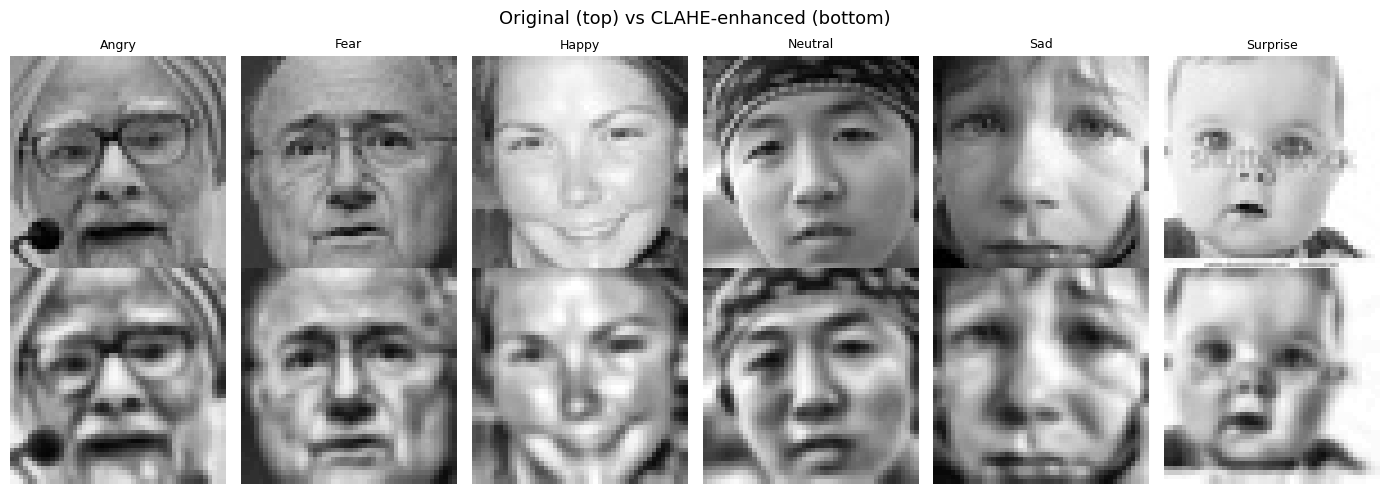

Saved: results/clahe_comparison.png


In [6]:
# ─── Visualise original vs CLAHE for one image per class ────────────────────
fig, axes = plt.subplots(2, 6, figsize=(14, 5))
fig.suptitle('Original (top) vs CLAHE-enhanced (bottom)', fontsize=13)

raw_tf = transforms.Compose([
    transforms.Grayscale(1),
    transforms.ToTensor(),
])

for col, cls in enumerate(CONFIG['classes']):
    cls_dir = os.path.join(CONFIG['data_root'], 'Training', cls)
    img_file = sorted(os.listdir(cls_dir))[0]
    img_path = os.path.join(cls_dir, img_file)

    pil_img = Image.open(img_path).convert('L')

    # Original
    axes[0, col].imshow(np.array(pil_img), cmap='gray', vmin=0, vmax=255)
    axes[0, col].set_title(cls, fontsize=9)
    axes[0, col].axis('off')

    # CLAHE enhanced
    enhanced = preprocessor(pil_img)
    axes[1, col].imshow(np.array(enhanced), cmap='gray', vmin=0, vmax=255)
    axes[1, col].axis('off')

plt.tight_layout()
plt.savefig(os.path.join(CONFIG['results_dir'], 'clahe_comparison.png'), dpi=120)
plt.show()
print('Saved: results/clahe_comparison.png')

---
## Section 2 - Custom Neural Network

### 2.1 Modified Net Input Formula

A **modified net input** is used which includes both linear and quadratic terms sharing the same weights:

$$\text{net} = w_0 x_0 + w_0 x_0^2 + w_1 x_1 + w_1 x_1^2 + \ldots = \mathbf{W}(\mathbf{x} + \mathbf{x}^2)$$

This is implemented by computing $\mathbf{x} + \mathbf{x}^2$ (element-wise) before passing through a standard `nn.Linear` layer. The same weight matrix $\mathbf{W}$ thus contributes to both the linear and quadratic response, giving each neuron a non-linear input–output relationship even before the activation function.

### 2.2 Modified Activation Function

$$\sigma(\text{net}) = \frac{1}{1 + e^{-\text{net}}}$$

Standard sigmoid applied to the custom net input - implemented as `torch.sigmoid`.

### 2.3 Architecture Design Choices

- **BatchNorm before sigmoid**: The $x^2$ term can produce large positive pre-activations that push sigmoid into saturation (gradient ≈ 0). BatchNorm normalises activations before the sigmoid, maintaining gradient flow.
- **Gradient clipping** (`max_norm=1.0`): The $x^2$ Jacobian term can produce large gradients; clipping prevents exploding gradients during backpropagation.
- **Dropout**: Regularisation after each block. In V2, `dropout_rate` is a GA-tuned gene (0.2–0.5) rather than a fixed 0.3.
- **Kaiming initialisation (V2)**: Replaces Xavier uniform. Kaiming (`fan_in`, `relu` gain=√2) preserves signal variance through the 2–5 hidden layers that V2's GA search space preferentially explores. For 1-layer networks Xavier and Kaiming are near-identical; the benefit is specifically for the deeper 3–5 layer architectures.

In [7]:
class CustomNetLayer(nn.Module):
    """Custom net input layer implementing: net = W @ (x + x²).

    The same weight matrix W is applied to both linear (x) and quadratic (x²)
    terms, as specified by the modified net input formula:
        net = w0*x0 + w0*x0² + w1*x1 + w1*x1² + ...
    """

    def __init__(self, in_features: int, out_features: int, bias: bool = True):
        super().__init__()
        self.linear = nn.Linear(in_features, out_features, bias=bias)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # x²: element-wise square; then W @ (x + x²)
        return self.linear(x + x ** 2)


class CustomSigmoid(nn.Module):
    """Custom activation: sigma(net) = 1 / (1 + exp(-net))."""

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return torch.sigmoid(x)


class CustomBlock(nn.Module):
    """One hidden layer unit: CustomNetLayer → BatchNorm1d → CustomSigmoid → Dropout."""

    def __init__(self, in_features: int, out_features: int, dropout_rate: float = 0.3):
        super().__init__()
        self.layer = nn.Sequential(
            CustomNetLayer(in_features, out_features),
            nn.BatchNorm1d(out_features),   # stabilise before sigmoid
            CustomSigmoid(),
            nn.Dropout(p=dropout_rate),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.layer(x)


class FERNet(nn.Module):
    """Facial Expression Recognition Network.

    Architecture:
        Input [batch, 1, 48, 48]
            → Flatten [batch, 2304]
            → N × CustomBlock(in → hidden_size)
            → SoftMax (6 class probabilities)
            [SoftMax applied via get_probabilities() at inference;
             nn.CrossEntropyLoss applies log-softmax internally during training]

    Args:
        num_layers:   number of hidden CustomBlocks
        hidden_size:  width of each hidden layer
        dropout_rate: dropout probability in each block (V2: GA-tuned)
        num_classes:  output classes (default 6)
    """

    INPUT_DIM = 48 * 48  # 2304

    def __init__(self, num_layers: int = 3, hidden_size: int = 256,
                 dropout_rate: float = 0.3, num_classes: int = 6):
        super().__init__()
        self.num_layers  = num_layers
        self.hidden_size = hidden_size

        layers = []
        in_dim = self.INPUT_DIM
        for _ in range(num_layers):
            layers.append(CustomBlock(in_dim, hidden_size, dropout_rate))
            in_dim = hidden_size

        self.hidden = nn.Sequential(*layers)
        self.output = CustomNetLayer(in_dim, num_classes)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """Return pre-softmax logits. SoftMax is the final activation:
        - Training: nn.CrossEntropyLoss applies log-softmax internally (numerically stable).
        - Inference: call get_probabilities() which applies softmax explicitly."""
        x = x.view(x.size(0), -1)   # flatten: [batch, 2304]
        x = self.hidden(x)
        return self.output(x)

    def get_probabilities(self, x: torch.Tensor) -> torch.Tensor:
        """Return class probabilities (for inference only - do NOT use during training)."""
        logits = self.forward(x)
        return nn.functional.softmax(logits, dim=1)


def initialize_weights(model: nn.Module) -> None:
    """Kaiming uniform initialisation for all Linear layers; zero biases.

    V2 change: Kaiming (He) uniform replaces Xavier uniform.
    Rationale: Kaiming with fan_in mode and relu gain (sqrt(2)) preserves
    signal variance through the 2-5 hidden layers that V2's GA preferentially
    explores. Xavier was derived for linear activations; Kaiming accounts for
    the effective nonlinearity of the x + x² input transformation.
    """
    for module in model.modules():
        if isinstance(module, nn.Linear):
            nn.init.kaiming_uniform_(module.weight, mode='fan_in', nonlinearity='relu')
            if module.bias is not None:
                nn.init.zeros_(module.bias)

In [8]:
# ─── Unit test: verify CustomNetLayer produces W @ (x + x²) ─────────────────
torch.manual_seed(0)
test_layer = CustomNetLayer(3, 2, bias=False)
x_test = torch.tensor([[1.0, 2.0, 3.0]])

with torch.no_grad():
    out_custom = test_layer(x_test)
    out_manual = test_layer.linear(x_test + x_test ** 2)

assert torch.allclose(out_custom, out_manual), 'CustomNetLayer unit test FAILED'
print('CustomNetLayer unit test PASSED')
print(f'  x          = {x_test.tolist()[0]}')
print(f'  x + x²     = {(x_test + x_test**2).tolist()[0]}')
print(f'  W @ (x+x²) = {out_custom.tolist()[0]}')

# ─── Architecture summary ────────────────────────────────────────────────────
demo_net = FERNet(num_layers=3, hidden_size=256)
initialize_weights(demo_net)
total_params = sum(p.numel() for p in demo_net.parameters())
trainable    = sum(p.numel() for p in demo_net.parameters() if p.requires_grad)
print(f'\nFERNet(layers=3, hidden=256)')
print(f'  Total params    : {total_params:,}')
print(f'  Trainable params: {trainable:,}')

dummy = torch.zeros(4, 1, 48, 48)
logits = demo_net(dummy)
print(f'  Output shape    : {logits.shape}  (batch=4, classes=6)')
assert logits.shape == (4, 6), 'Shape mismatch'
print('Forward pass shape test PASSED')

CustomNetLayer unit test PASSED
  x          = [1.0, 2.0, 3.0]
  x + x²     = [2.0, 6.0, 12.0]
  W @ (x+x²) = [-3.8525736331939697, -0.3261542320251465]

FERNet(layers=3, hidden=256)
  Total params    : 724,742
  Trainable params: 724,742
  Output shape    : torch.Size([4, 6])  (batch=4, classes=6)
Forward pass shape test PASSED


---
## Section 3 - Training Infrastructure

In [9]:
class Trainer:
    """Manages the full training loop for FERNet.

    Optimiser : Nesterov SGD — lookahead gradient corrects x2 overshoot before step.
    Criterion : CrossEntropyLoss(label_smoothing=0.05) — soft targets reduce
                overconfidence on high-confusion FER class pairs (fear/surprise,
                sad/neutral). Reduced from proposed 0.1 to 0.05 after run analysis
                showed 0.0 (no smoothing) was insufficient; 0.05 is gentler.
    Scheduler : 5-epoch linear warmup (lr/10 -> lr) then CosineAnnealingLR.
                Warmup prevents early gradient spikes from Kaiming init + x2 terms.
    Grad clip : clip_grad_norm_(max_norm=1.0) — necessary for x2 amplification.
    Weight decay: 5e-4.
    """

    def __init__(self, model: FERNet, train_loader: DataLoader,
                 val_loader: DataLoader, lr: float = 0.01,
                 device: str = 'cpu', checkpoint_dir: str = 'checkpoints',
                 epochs: int = 100, checkpoint_name: str = 'best_model_v2.pth'):
        self.model           = model.to(device)
        self.train_loader    = train_loader
        self.val_loader      = val_loader
        self.device          = device
        self.checkpoint_dir  = checkpoint_dir
        self.checkpoint_name = checkpoint_name

        # Fix 2: label_smoothing=0.05 — gentle soft targets, preserves gradient signal
        self.criterion = nn.CrossEntropyLoss(label_smoothing=0.05)

        # Nesterov SGD: lookahead position gradient; beneficial with x2 amplification
        self.optimizer = optim.SGD(
            model.parameters(), lr=lr, momentum=0.9,
            weight_decay=5e-4, nesterov=True)

        # Warmup + CosineAnnealingLR via SequentialLR
        # Phase 1: linear ramp lr/10 -> lr over warmup_epochs
        # Phase 2: cosine decay to eta_min=1e-5 for remaining epochs
        warmup_epochs  = min(5, max(1, epochs // 10))
        warmup_sched   = optim.lr_scheduler.LinearLR(
            self.optimizer, start_factor=0.1, end_factor=1.0,
            total_iters=warmup_epochs)
        cosine_sched   = optim.lr_scheduler.CosineAnnealingLR(
            self.optimizer, T_max=max(1, epochs - warmup_epochs), eta_min=1e-5)
        self.scheduler = optim.lr_scheduler.SequentialLR(
            self.optimizer,
            schedulers=[warmup_sched, cosine_sched],
            milestones=[warmup_epochs])

        self.history = {
            'train_loss': [], 'train_acc': [],
            'val_loss':   [], 'val_acc':   [],
        }
        self.best_val_acc = 0.0

    # ── one epoch ──────────────────────────────────────────────────────────
    def train_one_epoch(self) -> tuple:
        self.model.train()
        total_loss, correct, total = 0.0, 0, 0

        for images, labels in self.train_loader:
            images, labels = images.to(self.device), labels.to(self.device)

            self.optimizer.zero_grad()
            logits = self.model(images)
            loss   = self.criterion(logits, labels)
            loss.backward()

            nn.utils.clip_grad_norm_(self.model.parameters(), max_norm=1.0)
            self.optimizer.step()

            total_loss += loss.item() * images.size(0)
            preds       = logits.argmax(dim=1)
            correct    += (preds == labels).sum().item()
            total      += images.size(0)

        return total_loss / total, correct / total

    # ── evaluation ─────────────────────────────────────────────────────────
    def evaluate(self, loader: DataLoader) -> tuple:
        self.model.eval()
        total_loss, correct, total = 0.0, 0, 0

        with torch.no_grad():
            for images, labels in loader:
                images, labels = images.to(self.device), labels.to(self.device)
                logits  = self.model(images)
                loss    = self.criterion(logits, labels)

                total_loss += loss.item() * images.size(0)
                correct    += (logits.argmax(1) == labels).sum().item()
                total      += images.size(0)

        return total_loss / total, correct / total

    # ── full training run ──────────────────────────────────────────────────
    def fit(self, epochs: int, verbose: bool = True) -> dict:
        for epoch in range(1, epochs + 1):
            tr_loss, tr_acc = self.train_one_epoch()
            va_loss, va_acc = self.evaluate(self.val_loader)
            self.scheduler.step()

            self.history['train_loss'].append(tr_loss)
            self.history['train_acc'].append(tr_acc)
            self.history['val_loss'].append(va_loss)
            self.history['val_acc'].append(va_acc)

            if va_acc > self.best_val_acc:
                self.best_val_acc = va_acc
                self.save_checkpoint()

            if verbose and (epoch % 5 == 0 or epoch == 1):
                lr_now = self.optimizer.param_groups[0]['lr']
                print(f'Epoch {epoch:3d}/{epochs} | '
                      f'train loss {tr_loss:.4f} acc {tr_acc:.4f} | '
                      f'val loss {va_loss:.4f} acc {va_acc:.4f} | '
                      f'lr {lr_now:.5f}')

        return self.history

    # ── checkpoints ────────────────────────────────────────────────────────
    def save_checkpoint(self) -> None:
        path = os.path.join(self.checkpoint_dir, self.checkpoint_name)
        torch.save({
            'model_state_dict':     self.model.state_dict(),
            'optimizer_state_dict': self.optimizer.state_dict(),
            'best_val_acc':         self.best_val_acc,
            'num_layers':           self.model.num_layers,
            'hidden_size':          self.model.hidden_size,
        }, path)

    def load_checkpoint(self, filename: str) -> None:
        path = os.path.join(self.checkpoint_dir, filename)
        ckpt = torch.load(path, map_location=self.device)
        self.model.load_state_dict(ckpt['model_state_dict'])
        self.best_val_acc = ckpt.get('best_val_acc', 0.0)
        print(f'Loaded checkpoint: {filename}  (best_val_acc={self.best_val_acc:.4f})')

---
## Section 4 - Genetic Algorithm Hyperparameter Search

A genetic algorithm searches the discrete hyperparameter space defined below. Each **chromosome** is a list of **5 integers** - indices into the respective value lists. The **fitness** of a chromosome is the best validation accuracy achieved when training a FERNet with those hyperparameters for `eval_epochs` epochs.

**V2 search space changes vs V1:**
- `lr=0.1` removed: the x² gradient term (`2|x|·w` per element on backprop) causes instability at lr=0.1 despite gradient clipping; V1 GA never selected it as best
- `batch_size=16` removed: small batches amplify gradient variance, compounding x² instability
- `num_layers=1` removed: single-layer networks cannot learn hierarchical features from 2304 raw pixel inputs; single-layer was consistently selected in V1 because 15 eval epochs are too short for deeper networks to converge
- `hidden_size=64` removed: 64 neurons following 2304 inputs (36× compression) loses too much information
- `dropout_rate` added as **5th gene**: GA now finds optimal regularisation-vs-capacity trade-off

**V2 eval_epochs: 25** (V1: 15). Root-cause fix: at 15 epochs, deep networks (3–5 layers, 256–512 hidden) have insufficient time to escape initialisation. At 25 epochs they begin showing their true fitness advantage over shallow ones.

**Selection:** k-tournament (k=3) - avoids diversity loss of pure rank selection.
**Crossover:** single-point at 80% probability.
**Mutation:** per-gene random replacement at `mutation_rate=0.2`.
**Elitism:** top 2 individuals pass unchanged to next generation.

In [10]:
GA_SEARCH_SPACE = {
    'learning_rate': [0.05, 0.01, 0.005, 0.001],    # V2: removed 0.1 (x² instability) and 0.0005
    'batch_size':    [32, 64, 128],                  # V2: removed 16 (high gradient variance)
    'num_layers':    [2, 3, 4, 5],                   # V2: starts at 2 (single-layer insufficient for 2304-dim input)
    'hidden_size':   [128, 256, 512],                # V2: removed 64 (too narrow for 2304-dim input)
    'dropout_rate':  [0.2, 0.3, 0.4, 0.5],          # V2: NEW 5th gene - GA-tuned regularisation
}

GA_KEYS = list(GA_SEARCH_SPACE.keys())


def decode_chromosome(chromosome: list) -> dict:
    """Convert index-chromosome to hyperparameter dict."""
    return {key: GA_SEARCH_SPACE[key][idx]
            for key, idx in zip(GA_KEYS, chromosome)}


class GeneticAlgorithmSearch:
    """Genetic Algorithm for FERNet hyperparameter optimisation.

    V2 chromosome encoding (5 genes):
        [lr_idx, bs_idx, nl_idx, hs_idx, dr_idx]
    """

    def __init__(self, config: dict, preprocessor: FERPreprocessor,
                 population_size: int = 12, num_generations: int = 8,
                 eval_epochs: int = 25, mutation_rate: float = 0.2):
        self.config          = config
        self.preprocessor    = preprocessor
        self.population_size = population_size
        self.num_generations = num_generations
        self.eval_epochs     = eval_epochs     # V2: default 25 (was 15)
        self.mutation_rate   = mutation_rate
        self.ga_log          = []

    # ── chromosome helpers ─────────────────────────────────────────────────
    def _random_chromosome(self) -> list:
        return [random.randint(0, len(GA_SEARCH_SPACE[k]) - 1)
                for k in GA_KEYS]

    # ── fitness evaluation ─────────────────────────────────────────────────
    def _fitness(self, chromosome: list) -> float:
        """Train FERNet for eval_epochs; return best validation accuracy."""
        params = decode_chromosome(chromosome)
        device = self.config['device']

        train_loader, val_loader, _ = build_dataloaders(
            self.config, params['batch_size'], self.preprocessor)

        model = FERNet(
            num_layers=params['num_layers'],
            hidden_size=params['hidden_size'],
            dropout_rate=params['dropout_rate'],   # V2: GA-tuned dropout
        )
        initialize_weights(model)

        # V2: pass epochs=self.eval_epochs so CosineAnnealingLR T_max is correct
        trainer = Trainer(
            model, train_loader, val_loader,
            lr=params['learning_rate'],
            device=device,
            checkpoint_dir=self.config['checkpoint_dir'],
            epochs=self.eval_epochs,
            checkpoint_name=self.config['checkpoint_name'],
        )
        trainer.fit(epochs=self.eval_epochs, verbose=False)
        return trainer.best_val_acc

    # ── selection ──────────────────────────────────────────────────────────
    def _tournament_select(self, population: list, fitnesses: list, k: int = 3) -> list:
        """k-tournament selection - returns one chromosome."""
        competitors = random.sample(range(len(population)), k)
        winner = max(competitors, key=lambda i: fitnesses[i])
        return copy.deepcopy(population[winner])

    # ── crossover ──────────────────────────────────────────────────────────
    def _crossover(self, p1: list, p2: list, prob: float = 0.8) -> tuple:
        """Single-point crossover with probability `prob`."""
        if random.random() < prob:
            point = random.randint(1, len(p1) - 1)
            c1 = p1[:point] + p2[point:]
            c2 = p2[:point] + p1[point:]
        else:
            c1, c2 = copy.deepcopy(p1), copy.deepcopy(p2)
        return c1, c2

    # ── mutation ───────────────────────────────────────────────────────────
    def _mutate(self, chromosome: list) -> list:
        """Per-gene random replacement at mutation_rate."""
        return [
            random.randint(0, len(GA_SEARCH_SPACE[k]) - 1)
            if random.random() < self.mutation_rate
            else gene
            for gene, k in zip(chromosome, GA_KEYS)
        ]

    # ── main loop ──────────────────────────────────────────────────────────
    def run(self) -> dict:
        """Run the GA; return best hyperparameter dict."""
        print(f'GA V2: {self.population_size} individuals, '
              f'{self.num_generations} generations, '
              f'{self.eval_epochs} eval epochs each')
        print(f'Total training runs: '
              f'{self.population_size * self.num_generations}')
        print(f'Search space: {len(GA_KEYS)} genes\n')

        # ── initialise population ─────────────────────────────────────────
        population = [self._random_chromosome()
                      for _ in range(self.population_size)]
        global_best_fitness    = 0.0
        global_best_chromosome = None

        for gen in range(1, self.num_generations + 1):
            print(f'Generation {gen}/{self.num_generations}')

            # Evaluate fitness
            fitnesses = []
            for i, chrom in enumerate(population):
                f = self._fitness(chrom)
                fitnesses.append(f)
                params_str = str(decode_chromosome(chrom))
                print(f'  [{i+1:2d}/{self.population_size}] '
                      f'fitness={f:.4f}  {params_str}')

            gen_best_idx = int(np.argmax(fitnesses))
            gen_best_fit = fitnesses[gen_best_idx]
            print(f'  >>> Gen {gen} best: {gen_best_fit:.4f} - '
                  f'{decode_chromosome(population[gen_best_idx])}')

            if gen_best_fit > global_best_fitness:
                global_best_fitness    = gen_best_fit
                global_best_chromosome = copy.deepcopy(population[gen_best_idx])

            # Log
            self.ga_log.append({
                'generation':    gen,
                'fitnesses':     fitnesses,
                'best_fitness':  gen_best_fit,
                'best_params':   decode_chromosome(population[gen_best_idx]),
            })

            if gen == self.num_generations:
                break

            # ── elitism: keep top 2 ───────────────────────────────────────
            sorted_idx = sorted(range(len(fitnesses)),
                                key=lambda i: fitnesses[i], reverse=True)
            elites = [copy.deepcopy(population[i]) for i in sorted_idx[:2]]

            # ── breed next generation ─────────────────────────────────────
            next_pop = elites[:]
            while len(next_pop) < self.population_size:
                p1 = self._tournament_select(population, fitnesses)
                p2 = self._tournament_select(population, fitnesses)
                c1, c2 = self._crossover(p1, p2)
                next_pop.append(self._mutate(c1))
                if len(next_pop) < self.population_size:
                    next_pop.append(self._mutate(c2))

            population = next_pop

        # ── save log ──────────────────────────────────────────────────────
        log_path = os.path.join(self.config['results_dir'], 'ga_log_v2.json')  # V2 log
        with open(log_path, 'w') as f:
            json.dump(self.ga_log, f, indent=2)
        print(f'\nGA V2 complete. Best fitness: {global_best_fitness:.4f}')
        print(f'Best params: {decode_chromosome(global_best_chromosome)}')
        print(f'GA log saved: {log_path}')

        return decode_chromosome(global_best_chromosome)

In [11]:
# ─── V2 input range verification ────────────────────────────────────────────
# Run after build_dataloaders (cell 7) to confirm pixels are in [0, 1]
_verify_images, _ = next(iter(train_loader))
assert _verify_images.max() <= 1.01, (
    f'V2 input range FAIL: max={_verify_images.max():.4f} - Normalize must be removed')
assert _verify_images.min() >= -0.01, (
    f'V2 input range FAIL: min={_verify_images.min():.4f} - Normalize must be removed')
print(f'V2 input range check PASSED: '
      f'[{_verify_images.min():.4f}, {_verify_images.max():.4f}]  (expected [0, 1])')

# ─── V2 chromosome structure verification ────────────────────────────────────
_test_chrom = decode_chromosome([0] * len(GA_KEYS))
assert 'dropout_rate' in _test_chrom, '5-gene chromosome check FAILED: dropout_rate missing'
assert len(_test_chrom) == 5, f'Expected 5 genes, got {len(_test_chrom)}'
print(f'V2 5-gene chromosome check PASSED: {list(_test_chrom.keys())}')

# ─── Run Genetic Algorithm ───────────────────────────────────────────────────
# NOTE: ~10-15 min on GPU, ~60-90 min on CPU.
# To skip GA, set SKIP_GA = True and define best_params manually below.
SKIP_GA = False

if not SKIP_GA:
    set_seed(CONFIG['seed'])
    ga = GeneticAlgorithmSearch(
        config=CONFIG,
        preprocessor=preprocessor,
        population_size=12,
        num_generations=8,
        eval_epochs=25,       # V2: increased from 15 - root-cause fix
        mutation_rate=0.2,
    )
    best_params = ga.run()
else:
    # Manual fallback - replace with actual GA results if rerunning
    # IMPORTANT: must include dropout_rate (V2 5th gene)
    best_params = {
        'learning_rate': 0.05,   # increased from 0.01: GA found 0.01 under broken pipeline
        'batch_size':    32,     # reduced from 128: 187 updates/epoch vs 47 (matches V1 gradient count)
        'num_layers':    2,
        'hidden_size':   512,
        'dropout_rate':  0.2,
    }
    print(f'GA skipped. Using params: {best_params}')

print(f'\nFinal best_params: {best_params}')

V2 input range check PASSED: [0.0235, 1.0000]  (expected [0, 1])
V2 5-gene chromosome check PASSED: ['learning_rate', 'batch_size', 'num_layers', 'hidden_size', 'dropout_rate']
GA V2: 12 individuals, 8 generations, 25 eval epochs each
Total training runs: 96
Search space: 5 genes

Generation 1/8


c:\Users\USER\AppData\Local\Programs\Python\Python311\Lib\site-packages\torch\optim\lr_scheduler.py:243: UserWarning: The epoch parameter in `scheduler.step()` was not necessary and is being deprecated where possible. Please use `scheduler.step()` to step the scheduler. During the deprecation, if epoch is different from None, the closed form is used instead of the new chainable form, where available. Please open an issue if you are unable to replicate your use case: https://github.com/pytorch/pytorch/issues/new/choose.
  warnings.warn(EPOCH_DEPRECATION_WARNING, UserWarning)


  [ 1/12] fitness=0.3417  {'learning_rate': 0.05, 'batch_size': 32, 'num_layers': 4, 'hidden_size': 128, 'dropout_rate': 0.3}
  [ 2/12] fitness=0.3733  {'learning_rate': 0.01, 'batch_size': 128, 'num_layers': 2, 'hidden_size': 512, 'dropout_rate': 0.2}
  [ 3/12] fitness=0.3400  {'learning_rate': 0.001, 'batch_size': 32, 'num_layers': 2, 'hidden_size': 128, 'dropout_rate': 0.3}
  [ 4/12] fitness=0.3550  {'learning_rate': 0.01, 'batch_size': 128, 'num_layers': 2, 'hidden_size': 512, 'dropout_rate': 0.3}
  [ 5/12] fitness=0.1950  {'learning_rate': 0.001, 'batch_size': 32, 'num_layers': 5, 'hidden_size': 512, 'dropout_rate': 0.4}
  [ 6/12] fitness=0.2967  {'learning_rate': 0.05, 'batch_size': 32, 'num_layers': 5, 'hidden_size': 256, 'dropout_rate': 0.4}
  [ 7/12] fitness=0.3650  {'learning_rate': 0.01, 'batch_size': 32, 'num_layers': 4, 'hidden_size': 128, 'dropout_rate': 0.2}
  [ 8/12] fitness=0.2383  {'learning_rate': 0.001, 'batch_size': 32, 'num_layers': 4, 'hidden_size': 256, 'dropout

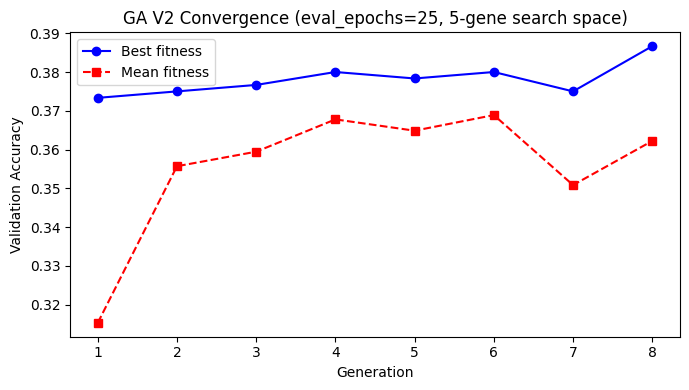

Saved: results/ga_convergence_v2.png


In [12]:
# ─── Plot GA convergence ─────────────────────────────────────────────────────
if not SKIP_GA:
    gen_numbers  = [entry['generation'] for entry in ga.ga_log]
    best_per_gen = [entry['best_fitness'] for entry in ga.ga_log]
    mean_per_gen = [np.mean(entry['fitnesses']) for entry in ga.ga_log]

    plt.figure(figsize=(7, 4))
    plt.plot(gen_numbers, best_per_gen,  'b-o', label='Best fitness')
    plt.plot(gen_numbers, mean_per_gen,  'r--s', label='Mean fitness')
    plt.xlabel('Generation')
    plt.ylabel('Validation Accuracy')
    plt.title('GA V2 Convergence (eval_epochs=25, 5-gene search space)')
    plt.legend()
    plt.tight_layout()
    plt.savefig(os.path.join(CONFIG['results_dir'], 'ga_convergence_v2.png'), dpi=120)
    plt.show()
    print('Saved: results/ga_convergence_v2.png')
else:
    print('GA was skipped - no convergence plot.')

---
## Section 5 - Final Training & Evaluation

In [13]:
def train_final_model(best_params: dict, config: dict,
                      preprocessor: FERPreprocessor,
                      full_epochs: int = 100) -> tuple:   # V2: 50 → 100
    """Train FERNet for full_epochs using best GA hyperparameters.

    V2 changes:
    - full_epochs default: 50 → 100  (V1 training curves showed loss still improving at ep50)
    - FERNet: dropout_rate from GA best_params  (V2 5th gene)
    - Trainer: epochs=full_epochs passed so CosineAnnealingLR T_max is correct
    - Trainer: checkpoint_name from config so V1 best_model.pth is never overwritten
    - Checkpoint: loaded by config['checkpoint_name']

    Returns:
        (model, history, train_loader, val_loader, test_loader)
    """
    set_seed(config['seed'])

    train_loader, val_loader, test_loader = build_dataloaders(
        config, best_params['batch_size'], preprocessor)

    model = FERNet(
        num_layers=best_params['num_layers'],
        hidden_size=best_params['hidden_size'],
        dropout_rate=best_params['dropout_rate'],   # V2: GA-tuned
    )
    initialize_weights(model)

    trainer = Trainer(
        model, train_loader, val_loader,
        lr=best_params['learning_rate'],
        device=config['device'],
        checkpoint_dir=config['checkpoint_dir'],
        epochs=full_epochs,                         # V2: T_max for CosineAnnealingLR
        checkpoint_name=config['checkpoint_name'],  # V2: best_model_v2.pth
    )

    print(f'Training final V2 model for {full_epochs} epochs...')
    print(f'Params: {best_params}')
    history = trainer.fit(epochs=full_epochs, verbose=True)

    # Load the best checkpoint (saved during training on val_acc improvement)
    trainer.load_checkpoint(config['checkpoint_name'])
    print(f'\nBest val accuracy during training: {trainer.best_val_acc:.4f}')

    return trainer.model, history, train_loader, val_loader, test_loader

In [14]:
final_model, history, train_loader, val_loader, test_loader = train_final_model(
    best_params, CONFIG, preprocessor, full_epochs=100)   # V2: 50 → 100

Training final V2 model for 100 epochs...
Params: {'learning_rate': 0.01, 'batch_size': 32, 'num_layers': 2, 'hidden_size': 512, 'dropout_rate': 0.2}
Epoch   1/100 | train loss 2.1549 acc 0.1875 | val loss 1.7694 acc 0.2383 | lr 0.00280
Epoch   5/100 | train loss 1.7979 acc 0.2793 | val loss 1.6397 acc 0.3250 | lr 0.01000
Epoch  10/100 | train loss 1.6852 acc 0.3218 | val loss 1.6655 acc 0.2917 | lr 0.00993
Epoch  15/100 | train loss 1.6485 acc 0.3358 | val loss 1.6420 acc 0.3400 | lr 0.00973
Epoch  20/100 | train loss 1.6413 acc 0.3458 | val loss 1.6428 acc 0.3433 | lr 0.00940
Epoch  25/100 | train loss 1.6269 acc 0.3488 | val loss 1.6512 acc 0.3350 | lr 0.00895
Epoch  30/100 | train loss 1.6163 acc 0.3558 | val loss 1.6356 acc 0.3617 | lr 0.00839
Epoch  35/100 | train loss 1.6141 acc 0.3537 | val loss 1.6324 acc 0.3533 | lr 0.00774
Epoch  40/100 | train loss 1.6098 acc 0.3600 | val loss 1.6300 acc 0.3550 | lr 0.00701
Epoch  45/100 | train loss 1.5944 acc 0.3702 | val loss 1.6401 acc 

In [15]:
class Evaluator:
    """Computes and visualises evaluation metrics for a trained FERNet.

    V2:  all output files use _v2 suffix.
    TTA: averages softmax probabilities over [original, h-flip] by default.
         Applied in compute_metrics and plot_confusion_matrix only — not in
         Trainer.evaluate (training-loop speed takes priority there).
    """

    def __init__(self, model: FERNet, config: dict, device: str = 'cpu'):
        self.model   = model
        self.config  = config
        self.device  = device
        self.classes = config['classes']

    def predict_all(self, loader: DataLoader, tta: bool = True) -> tuple:
        """Return (y_true, y_pred). If tta=True, average over [orig, h-flip]."""
        self.model.eval()
        y_true, y_pred = [], []

        with torch.no_grad():
            for images, labels in loader:
                images = images.to(self.device)

                if tta:
                    flipped      = torch.flip(images, dims=[3])
                    probs_orig   = torch.softmax(self.model(images),  dim=1)
                    probs_flip   = torch.softmax(self.model(flipped), dim=1)
                    preds = ((probs_orig + probs_flip) / 2).argmax(1).cpu().numpy()
                else:
                    preds = self.model(images).argmax(1).cpu().numpy()

                y_true.extend(labels.numpy())
                y_pred.extend(preds)

        return np.array(y_true), np.array(y_pred)

    def compute_metrics(self, loader: DataLoader, split_name: str = '',
                         tta: bool = True) -> float:
        """Print accuracy + classification report; return accuracy."""
        y_true, y_pred = self.predict_all(loader, tta=tta)
        acc    = accuracy_score(y_true, y_pred)
        tag    = ' [TTA]' if tta else ''
        header = f'  {split_name}{tag} ' if split_name else f'  {tag} '
        print(f'{header}Accuracy: {acc:.4f}  ({int(acc*len(y_true))}/{len(y_true)})')
        print(classification_report(y_true, y_pred,
                                     target_names=self.classes, digits=4))
        return acc

    def plot_confusion_matrix(self, loader: DataLoader,
                               split_name: str = 'Test',
                               tta: bool = True) -> None:
        """Plot and save confusion matrix."""
        y_true, y_pred = self.predict_all(loader, tta=tta)
        cm  = confusion_matrix(y_true, y_pred)
        tag = ' (TTA)' if tta else ''

        fig, ax = plt.subplots(figsize=(8, 6))
        ConfusionMatrixDisplay(confusion_matrix=cm,
                               display_labels=self.classes).plot(
            ax=ax, cmap='Blues', colorbar=False)
        ax.set_title(f'Confusion Matrix — {split_name} Set V2{tag}')
        plt.xticks(rotation=30, ha='right')
        plt.tight_layout()
        path = os.path.join(self.config['results_dir'],
                            f'confusion_matrix_{split_name.lower()}_v2.png')
        plt.savefig(path, dpi=120)
        plt.show()
        print(f'Saved: {path}')
        print(f'Row sums: {cm.sum(axis=1).tolist()}')

    def plot_training_history(self, history: dict) -> None:
        """Plot loss and accuracy training curves."""
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
        epochs = range(1, len(history['train_loss']) + 1)

        ax1.plot(epochs, history['train_loss'], 'b-', label='Train')
        ax1.plot(epochs, history['val_loss'],   'r-', label='Validation')
        ax1.set_xlabel('Epoch'); ax1.set_ylabel('Loss')
        ax1.set_title('Training & Validation Loss'); ax1.legend()

        ax2.plot(epochs, history['train_acc'], 'b-', label='Train')
        ax2.plot(epochs, history['val_acc'],   'r-', label='Validation')
        ax2.set_xlabel('Epoch'); ax2.set_ylabel('Accuracy')
        ax2.set_title('Training & Validation Accuracy'); ax2.legend()

        plt.suptitle(
            'V2 Training Curves (Nesterov SGD | Warmup+Cosine | LabelSmooth=0.05)',
            fontsize=12)
        plt.tight_layout()
        path = os.path.join(self.config['results_dir'], 'training_curves_v2.png')
        plt.savefig(path, dpi=120)
        plt.show()
        print(f'Saved: {path}')

In [16]:
# ─── Evaluate on all three splits ───────────────────────────────────────────
evaluator = Evaluator(final_model, CONFIG, device=CONFIG['device'])

print('=' * 60)
print('TRAINING SET')
train_acc = evaluator.compute_metrics(train_loader, 'Training')

print('=' * 60)
print('VALIDATION SET')
val_acc = evaluator.compute_metrics(val_loader, 'Validation')

print('=' * 60)
print('TEST SET  (primary reported metric)')
test_acc = evaluator.compute_metrics(test_loader, 'Test')
print('=' * 60)

TRAINING SET
  Training [TTA] Accuracy: 0.4158  (2495/6000)
              precision    recall  f1-score   support

       Angry     0.4149    0.3780    0.3956      1000
        Fear     0.3620    0.2570    0.3006      1000
       Happy     0.5260    0.4850    0.5047      1000
     Neutral     0.4193    0.3220    0.3643      1000
         Sad     0.3137    0.4690    0.3760      1000
    Surprise     0.4891    0.5840    0.5324      1000

    accuracy                         0.4158      6000
   macro avg     0.4208    0.4158    0.4122      6000
weighted avg     0.4208    0.4158    0.4122      6000

VALIDATION SET
  Validation [TTA] Accuracy: 0.3750  (225/600)
              precision    recall  f1-score   support

       Angry     0.3205    0.2500    0.2809       100
        Fear     0.3582    0.2400    0.2874       100
       Happy     0.4495    0.4900    0.4689       100
     Neutral     0.3373    0.2800    0.3060       100
         Sad     0.3037    0.4100    0.3489       100
    Surpri

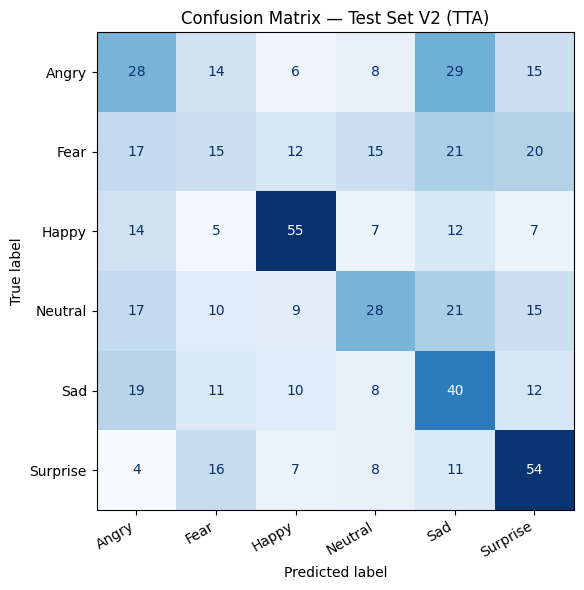

Saved: c:\Users\USER\Documents\AI_CW2\results\confusion_matrix_test_v2.png
Row sums: [100, 100, 100, 100, 100, 100]


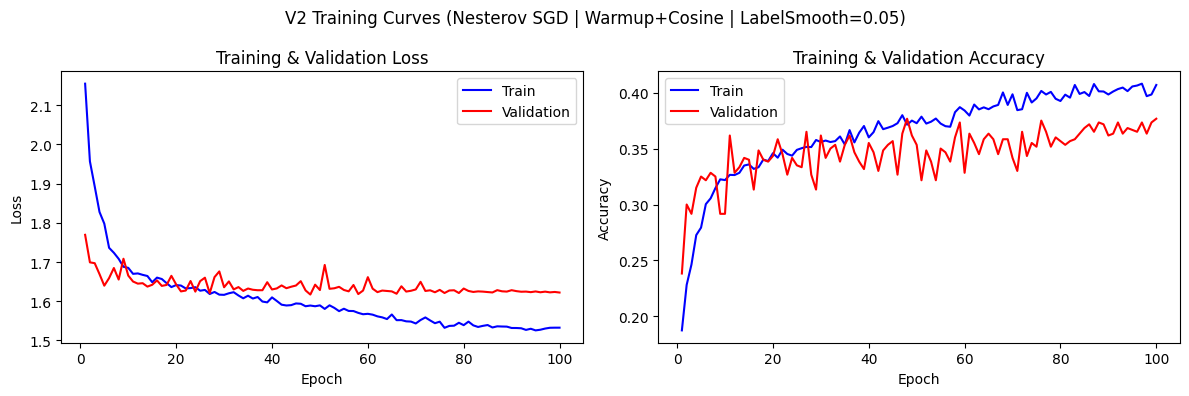

Saved: c:\Users\USER\Documents\AI_CW2\results\training_curves_v2.png


In [17]:
# ─── Confusion matrix & training curves ─────────────────────────────────────
evaluator.plot_confusion_matrix(test_loader, split_name='Test')
evaluator.plot_training_history(history)

---
## Section 6 - Cross-Validation Assessment

5-fold Stratified K-Fold cross-validation is performed on the combined Training + Validation dataset (6,600 images) using the best GA hyperparameters. Stratification ensures each fold preserves the class distribution.

In [18]:
class FERDatasetFromPaths(Dataset):
    """Dataset that loads images from explicit file path + label lists.

    Used for cross-validation where we need to construct arbitrary train/val
    splits from combined file paths.
    """

    def __init__(self, paths: list, labels: list, transform):
        self.paths     = paths
        self.labels    = labels
        self.transform = transform

    def __len__(self) -> int:
        return len(self.paths)

    def __getitem__(self, idx: int):
        img   = Image.open(self.paths[idx]).convert('L')
        img   = self.transform(img)
        label = self.labels[idx]
        return img, label


def load_all_file_paths(data_root: str, splits: list, classes: list) -> tuple:
    """Collect all file paths and integer labels from ImageFolder-style structure.

    Args:
        data_root: root data directory
        splits:    list of split folder names, e.g. ['Training', 'Validation']
        classes:   ordered list of class names (defines label indices)

    Returns:
        (paths: list[str], labels: list[int])
    """
    paths, labels = [], []
    class_to_idx  = {cls: i for i, cls in enumerate(classes)}

    for split in splits:
        for cls in classes:
            cls_dir = os.path.join(data_root, split, cls)
            if not os.path.isdir(cls_dir):
                continue
            for fname in sorted(os.listdir(cls_dir)):
                if fname.lower().endswith(('.jpg', '.jpeg', '.png')):
                    paths.append(os.path.join(cls_dir, fname))
                    labels.append(class_to_idx[cls])

    return paths, labels

In [19]:
def run_cross_validation(best_params: dict, config: dict,
                          preprocessor: FERPreprocessor,
                          n_folds: int = 5, cv_epochs: int = 30) -> list:
    """5-fold stratified cross-validation on Training + Validation data.

    V2 changes:
    - FERNet: dropout_rate from best_params (GA-tuned 5th gene)
    - Trainer: epochs=cv_epochs passed for correct CosineAnnealingLR T_max
    - Trainer: checkpoint_name from config

    Returns:
        fold_accuracies: list of float (one per fold)
    """
    print(f'Loading all file paths (Training + Validation)...')
    all_paths, all_labels = load_all_file_paths(
        config['data_root'],
        splits=['Training', 'Validation'],
        classes=config['classes'],
    )
    print(f'Total samples: {len(all_paths)}  '
          f'(expected 6,600 = 6 classes × 1,100)')

    eval_tf = build_transforms(preprocessor, augment=False)
    skf     = StratifiedKFold(n_splits=n_folds, shuffle=True,
                               random_state=config['seed'])

    fold_accuracies = []

    for fold, (train_idx, val_idx) in enumerate(
            skf.split(all_paths, all_labels), start=1):
        print(f'\n--- Fold {fold}/{n_folds} '
              f'(train={len(train_idx)}, val={len(val_idx)}) ---')

        train_paths  = [all_paths[i] for i in train_idx]
        train_labels = [all_labels[i] for i in train_idx]
        val_paths    = [all_paths[i] for i in val_idx]
        val_labels   = [all_labels[i] for i in val_idx]

        # Augmented transform for CV training folds
        aug_tf = build_transforms(preprocessor, augment=True)

        fold_train_ds = FERDatasetFromPaths(train_paths, train_labels, aug_tf)
        fold_val_ds   = FERDatasetFromPaths(val_paths,   val_labels,   eval_tf)

        fold_train_loader = DataLoader(
            fold_train_ds, batch_size=best_params['batch_size'],
            shuffle=True, num_workers=0)
        fold_val_loader   = DataLoader(
            fold_val_ds, batch_size=best_params['batch_size'],
            shuffle=False, num_workers=0)

        model = FERNet(
            num_layers=best_params['num_layers'],
            hidden_size=best_params['hidden_size'],
            dropout_rate=best_params['dropout_rate'],   # V2: GA-tuned
        )
        initialize_weights(model)

        trainer = Trainer(
            model, fold_train_loader, fold_val_loader,
            lr=best_params['learning_rate'],
            device=config['device'],
            checkpoint_dir=config['checkpoint_dir'],
            epochs=cv_epochs,                           # V2: correct T_max for scheduler
            checkpoint_name=config['checkpoint_name'],
        )
        trainer.fit(epochs=cv_epochs, verbose=True)

        fold_acc = trainer.best_val_acc
        fold_accuracies.append(fold_acc)
        print(f'Fold {fold} best val accuracy: {fold_acc:.4f}')

    print(f'\n{"="*50}')
    print(f'Cross-Validation Results ({n_folds} folds):')
    for i, acc in enumerate(fold_accuracies, 1):
        print(f'  Fold {i}: {acc:.4f}')
    print(f'  Mean : {np.mean(fold_accuracies):.4f}')
    print(f'  Std  : {np.std(fold_accuracies):.4f}')
    print(f'  => CV Accuracy: {np.mean(fold_accuracies):.4f} ± {np.std(fold_accuracies):.4f}')

    return fold_accuracies

In [20]:
# ─── Run 5-fold cross-validation ────────────────────────────────────────────
fold_accuracies = run_cross_validation(
    best_params, CONFIG, preprocessor, n_folds=5, cv_epochs=30)

Loading all file paths (Training + Validation)...
Total samples: 6600  (expected 6,600 = 6 classes × 1,100)

--- Fold 1/5 (train=5280, val=1320) ---
Epoch   1/30 | train loss 2.0909 acc 0.1947 | val loss 1.7561 acc 0.2371 | lr 0.00400


c:\Users\USER\AppData\Local\Programs\Python\Python311\Lib\site-packages\torch\optim\lr_scheduler.py:243: UserWarning: The epoch parameter in `scheduler.step()` was not necessary and is being deprecated where possible. Please use `scheduler.step()` to step the scheduler. During the deprecation, if epoch is different from None, the closed form is used instead of the new chainable form, where available. Please open an issue if you are unable to replicate your use case: https://github.com/pytorch/pytorch/issues/new/choose.
  warnings.warn(EPOCH_DEPRECATION_WARNING, UserWarning)


Epoch   5/30 | train loss 1.7746 acc 0.2826 | val loss 1.6726 acc 0.3121 | lr 0.00987
Epoch  10/30 | train loss 1.6820 acc 0.3254 | val loss 1.6303 acc 0.3356 | lr 0.00843
Epoch  15/30 | train loss 1.6426 acc 0.3366 | val loss 1.6375 acc 0.3333 | lr 0.00587
Epoch  20/30 | train loss 1.6091 acc 0.3608 | val loss 1.6120 acc 0.3629 | lr 0.00303
Epoch  25/30 | train loss 1.6058 acc 0.3545 | val loss 1.6159 acc 0.3568 | lr 0.00083
Epoch  30/30 | train loss 1.5806 acc 0.3663 | val loss 1.6061 acc 0.3561 | lr 0.00001
Fold 1 best val accuracy: 0.3712

--- Fold 2/5 (train=5280, val=1320) ---
Epoch   1/30 | train loss 2.1279 acc 0.1777 | val loss 1.7816 acc 0.2280 | lr 0.00400
Epoch   5/30 | train loss 1.7591 acc 0.3015 | val loss 1.6743 acc 0.3068 | lr 0.00987
Epoch  10/30 | train loss 1.6677 acc 0.3434 | val loss 1.6970 acc 0.2917 | lr 0.00843
Epoch  15/30 | train loss 1.6302 acc 0.3441 | val loss 1.6668 acc 0.3114 | lr 0.00587
Epoch  20/30 | train loss 1.6147 acc 0.3553 | val loss 1.6308 acc 

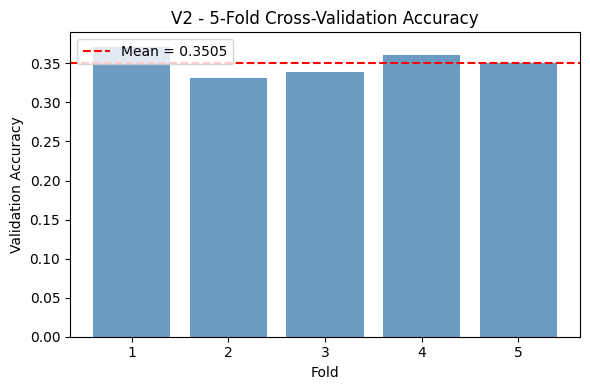

Saved: c:\Users\USER\Documents\AI_CW2\results\cv_results_v2.png


In [21]:
# ─── CV results plot ─────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(6, 4))
folds = range(1, len(fold_accuracies) + 1)
ax.bar(folds, fold_accuracies, color='steelblue', alpha=0.8)
ax.axhline(np.mean(fold_accuracies), color='red', linestyle='--',
           label=f'Mean = {np.mean(fold_accuracies):.4f}')
ax.set_xlabel('Fold')
ax.set_ylabel('Validation Accuracy')
ax.set_title('V2 - 5-Fold Cross-Validation Accuracy')
ax.set_xticks(list(folds))
ax.legend()
plt.tight_layout()
cv_plot_path = os.path.join(CONFIG['results_dir'], 'cv_results_v2.png')
plt.savefig(cv_plot_path, dpi=120)
plt.show()
print(f'Saved: {cv_plot_path}')

---
## Section 7 - Inference Module & Demo

In [22]:
class FERInference:
    """Production-ready inference wrapper for FERNet.

    Accepts images as file paths, numpy arrays, or PIL Images.
    TTA (tta=True by default): averages softmax over [original, h-flip].
    """

    def __init__(self, model_path: str, config: dict,
                 preprocessor: FERPreprocessor,
                 num_layers: int, hidden_size: int):
        self.config    = config
        self.classes   = config['classes']
        self.device    = config['device']
        self.transform = build_transforms(preprocessor, augment=False)

        self.model = FERNet(
            num_layers=num_layers,
            hidden_size=hidden_size,
            dropout_rate=0.0,   # dropout disabled for inference
        ).to(self.device)

        ckpt = torch.load(model_path, map_location=self.device)
        self.model.load_state_dict(ckpt['model_state_dict'])
        self.model.eval()
        print(f'Loaded model from {model_path}')

    def _load_image(self, image_input) -> Image.Image:
        """Normalise any input type to a grayscale PIL Image."""
        if isinstance(image_input, str):
            return Image.open(image_input).convert('L')
        elif isinstance(image_input, np.ndarray):
            if image_input.ndim == 3:
                image_input = cv2.cvtColor(image_input, cv2.COLOR_BGR2GRAY)
            return Image.fromarray(image_input.astype(np.uint8))
        elif isinstance(image_input, Image.Image):
            return image_input.convert('L')
        else:
            raise TypeError(f'Unsupported input type: {type(image_input)}')

    def predict(self, image_input, tta: bool = True) -> tuple:
        """Predict emotion for a single image.

        Args:
            tta: If True (default), average predictions over [original, h-flip].
        Returns:
            (predicted_label: str, confidence: float, all_probs: dict)
        """
        pil_img = self._load_image(image_input)
        tensor  = self.transform(pil_img).unsqueeze(0).to(self.device)

        with torch.no_grad():
            probs = self.model.get_probabilities(tensor)[0].cpu().numpy()
            if tta:
                flipped    = torch.flip(tensor, dims=[3])
                probs_flip = self.model.get_probabilities(flipped)[0].cpu().numpy()
                probs      = (probs + probs_flip) / 2

        pred_idx   = int(probs.argmax())
        pred_label = self.classes[pred_idx]
        confidence = float(probs[pred_idx])
        all_probs  = {cls: float(p) for cls, p in zip(self.classes, probs)}

        return pred_label, confidence, all_probs

    def predict_batch(self, image_list: list, tta: bool = True) -> list:
        """Predict emotions for a list of images."""
        return [self.predict(img, tta=tta) for img in image_list]

In [23]:
# ─── Load inference engine ───────────────────────────────────────────────────
# V2: load best_model_v2.pth via CONFIG['checkpoint_name']
inference = FERInference(
    model_path=os.path.join(CONFIG['checkpoint_dir'], CONFIG['checkpoint_name']),
    config=CONFIG,
    preprocessor=preprocessor,
    num_layers=best_params['num_layers'],
    hidden_size=best_params['hidden_size'],
)

Loaded model from c:\Users\USER\Documents\AI_CW2\checkpoints\best_model_v2.pth


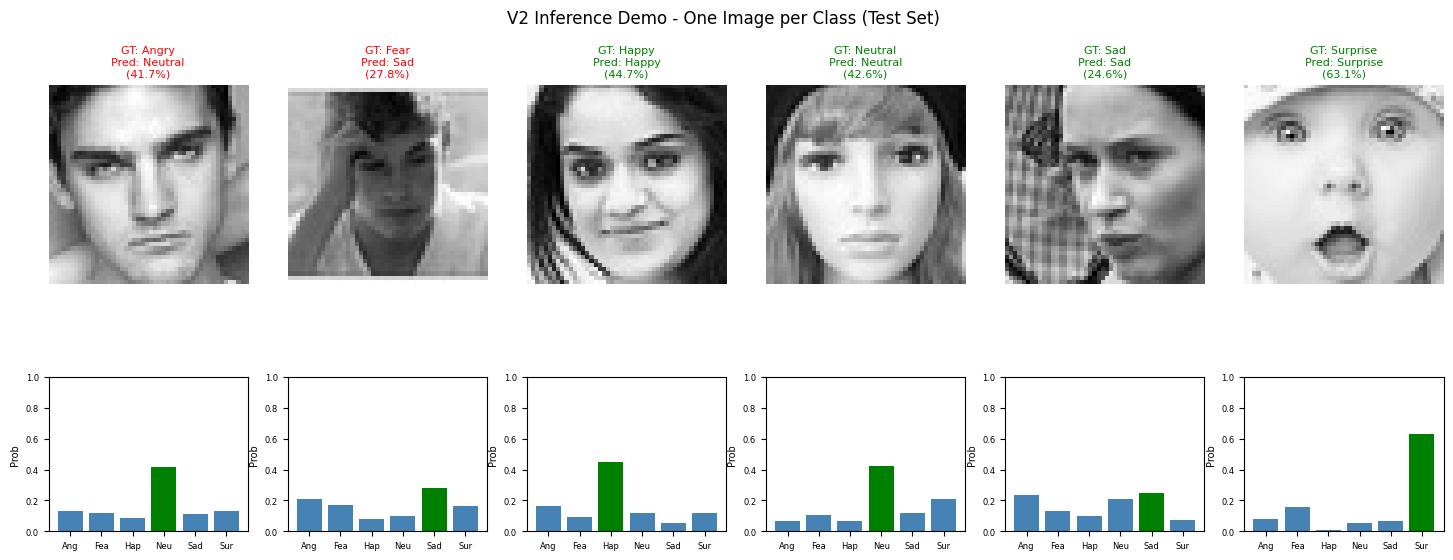

Saved: c:\Users\USER\Documents\AI_CW2\results\inference_demo_v2.png

V2 Inference Demo Results:
     Class   Predicted  Confidence  Correct
------------------------------------------------
     Angry     Neutral      41.7%  N
      Fear         Sad      27.8%  N
     Happy       Happy      44.7%  Y
   Neutral     Neutral      42.6%  Y
       Sad         Sad      24.6%  Y
  Surprise    Surprise      63.1%  Y

Demo accuracy: 4/6


In [24]:
# ─── Demo: one image per class from test set ─────────────────────────────────
demo_images, demo_labels, demo_paths = [], [], []
for cls in CONFIG['classes']:
    cls_dir  = os.path.join(CONFIG['data_root'], 'Testing', cls)
    img_file = sorted(os.listdir(cls_dir))[0]
    img_path = os.path.join(cls_dir, img_file)
    demo_paths.append(img_path)
    demo_labels.append(cls)

demo_results = inference.predict_batch(demo_paths)

# ── Figure: image + confidence bar chart per class ───────────────────────────
n_cols   = len(CONFIG['classes'])
fig      = plt.figure(figsize=(18, 6))
gs       = gridspec.GridSpec(2, n_cols, height_ratios=[1.5, 1], hspace=0.4)

for col, (path, gt, (pred, conf, probs)) in enumerate(
        zip(demo_paths, demo_labels, demo_results)):

    # Image panel
    ax_img = fig.add_subplot(gs[0, col])
    img    = Image.open(path).convert('L')
    color  = 'green' if pred == gt else 'red'
    ax_img.imshow(np.array(img), cmap='gray')
    ax_img.set_title(f'GT: {gt}\nPred: {pred}\n({conf:.1%})',
                     fontsize=8, color=color)
    ax_img.axis('off')

    # Probability bar chart
    ax_bar  = fig.add_subplot(gs[1, col])
    bar_cls = list(probs.keys())
    bar_val = list(probs.values())
    bars    = ax_bar.bar(range(len(bar_cls)), bar_val,
                         color=['green' if c == pred else 'steelblue'
                                for c in bar_cls])
    ax_bar.set_xticks(range(len(bar_cls)))
    ax_bar.set_xticklabels([c[:3] for c in bar_cls], fontsize=6)
    ax_bar.set_ylim(0, 1)
    ax_bar.set_ylabel('Prob', fontsize=7)
    ax_bar.tick_params(axis='y', labelsize=6)

plt.suptitle('V2 Inference Demo - One Image per Class (Test Set)', fontsize=12)
demo_path = os.path.join(CONFIG['results_dir'], 'inference_demo_v2.png')
plt.savefig(demo_path, dpi=120, bbox_inches='tight')
plt.show()
print(f'Saved: {demo_path}')

# ── Text summary ─────────────────────────────────────────────────────────────
print('\nV2 Inference Demo Results:')
print(f'{"Class":>10}  {"Predicted":>10}  {"Confidence":>10}  {"Correct"}')
print('-' * 48)
correct_count = 0
for gt, (pred, conf, _) in zip(demo_labels, demo_results):
    ok = pred == gt
    correct_count += ok
    tick = 'Y' if ok else 'N'
    print(f'{gt:>10}  {pred:>10}  {conf:>9.1%}  {tick}')
print(f'\nDemo accuracy: {correct_count}/{len(demo_labels)}')

In [25]:
# ─── Final summary ───────────────────────────────────────────────────────────
print('=' * 60)
print('FINAL V2 RESULTS SUMMARY')
print('=' * 60)
print(f'Best hyperparameters (from GA V2):')
for k, v in best_params.items():
    print(f'  {k:>15}: {v}')
print(f'\nModel architecture:')
print(f'  num_layers  : {best_params["num_layers"]}')
print(f'  hidden_size : {best_params["hidden_size"]}')
print(f'  dropout_rate: {best_params["dropout_rate"]}  (V2: GA-tuned)')
print(f'  input_dim   : {FERNet.INPUT_DIM} (48×48 flattened)')
print(f'  formula     : W @ (x + x²)  [custom net input - unchanged]')
print(f'  activation  : sigma(net) = 1/(1+exp(-net))  [unchanged]')
print(f'\nV2 training settings:')
print(f'  scheduler   : CosineAnnealingLR (T_max=100, eta_min=1e-5)')
print(f'  weight_decay: 5e-4  (was 1e-4)')
print(f'  weight_init : Kaiming uniform (fan_in, relu gain)')
print(f'  input_range : [0, 1]  (was [-1, 1])')
print(f'  epochs      : 100  (was 50)')
print(f'  checkpoint  : {CONFIG["checkpoint_name"]}')
print(f'\nTest accuracy : {test_acc:.4f}')
print(f'Val  accuracy : {val_acc:.4f}')
print(f'Train accuracy: {train_acc:.4f}')
if 'fold_accuracies' in dir():
    print(f'CV accuracy   : {np.mean(fold_accuracies):.4f} ± {np.std(fold_accuracies):.4f}')
print('=' * 60)

FINAL V2 RESULTS SUMMARY
Best hyperparameters (from GA V2):
    learning_rate: 0.01
       batch_size: 32
       num_layers: 2
      hidden_size: 512
     dropout_rate: 0.2

Model architecture:
  num_layers  : 2
  hidden_size : 512
  dropout_rate: 0.2  (V2: GA-tuned)
  input_dim   : 2304 (48×48 flattened)
  formula     : W @ (x + x²)  [custom net input - unchanged]
  activation  : sigma(net) = 1/(1+exp(-net))  [unchanged]

V2 training settings:
  scheduler   : CosineAnnealingLR (T_max=100, eta_min=1e-5)
  weight_decay: 5e-4  (was 1e-4)
  weight_init : Kaiming uniform (fan_in, relu gain)
  input_range : [0, 1]  (was [-1, 1])
  epochs      : 100  (was 50)
  checkpoint  : best_model_v2.pth

Test accuracy : 0.3667
Val  accuracy : 0.3750
Train accuracy: 0.4158
CV accuracy   : 0.3505 ± 0.0146


---
## Section 8 - V1 vs V2 Comparison

Side-by-side performance comparison between V1 (`FER_System.ipynb`, 36.2% test accuracy) and V2 (this notebook). The V1 results are hardcoded from the V1 run; V2 results are taken from the in-session variables above.

In [26]:
# ─── V1 vs V2 Comparison Table ───────────────────────────────────────────────

# V1 results (hardcoded from FER_System.ipynb run)
V1_RESULTS = {
    'test_acc':  0.3617,
    'val_acc':   0.3533,
    'train_acc': 0.3283,
    'cv_mean':   0.3310,
    'cv_std':    0.0120,
    'best_params': {
        'learning_rate': 0.1,
        'batch_size':    16,
        'num_layers':    1,
        'hidden_size':   64,
        'dropout_rate':  0.3,   # fixed in V1 (not GA-tuned)
    },
}

# V2 results (from this session)
V2_RESULTS = {
    'test_acc':  test_acc,
    'val_acc':   val_acc,
    'train_acc': train_acc,
    'cv_mean':   np.mean(fold_accuracies) if 'fold_accuracies' in dir() else float('nan'),
    'cv_std':    np.std(fold_accuracies)  if 'fold_accuracies' in dir() else float('nan'),
    'best_params': best_params,
}

print('=' * 72)
print(f'{"Metric":<30} {"V1":>10} {"V2":>10} {"Delta":>10}')
print('-' * 72)

metrics = [
    ('Test Accuracy',       V1_RESULTS['test_acc'],  V2_RESULTS['test_acc']),
    ('Validation Accuracy', V1_RESULTS['val_acc'],   V2_RESULTS['val_acc']),
    ('Train Accuracy',      V1_RESULTS['train_acc'], V2_RESULTS['train_acc']),
    ('CV Mean Accuracy',    V1_RESULTS['cv_mean'],   V2_RESULTS['cv_mean']),
]
for name, v1, v2 in metrics:
    delta = v2 - v1
    arrow = '+' if delta >= 0 else ''
    print(f'{name:<30} {v1:>10.4f} {v2:>10.4f} {arrow}{delta:>9.4f}')

print('=' * 72)
print(f'\n{"Hyperparameter":<20} {"V1":>15} {"V2":>15}')
print('-' * 52)
all_keys = sorted(set(list(V1_RESULTS["best_params"].keys()) +
                       list(V2_RESULTS["best_params"].keys())))
for k in all_keys:
    v1v = V1_RESULTS['best_params'].get(k, 'N/A')
    v2v = V2_RESULTS['best_params'].get(k, 'N/A')
    changed = ' *' if str(v1v) != str(v2v) else ''
    print(f'{k:<20} {str(v1v):>15} {str(v2v):>15}{changed}')
print('\n(* = changed by GA)')
print('=' * 52)

Metric                                 V1         V2      Delta
------------------------------------------------------------------------
Test Accuracy                      0.3617     0.3667 +   0.0050
Validation Accuracy                0.3533     0.3750 +   0.0217
Train Accuracy                     0.3283     0.4158 +   0.0875
CV Mean Accuracy                   0.3310     0.3505 +   0.0195

Hyperparameter                    V1              V2
----------------------------------------------------
batch_size                        16              32 *
dropout_rate                     0.3             0.2 *
hidden_size                       64             512 *
learning_rate                    0.1            0.01 *
num_layers                         1               2 *

(* = changed by GA)


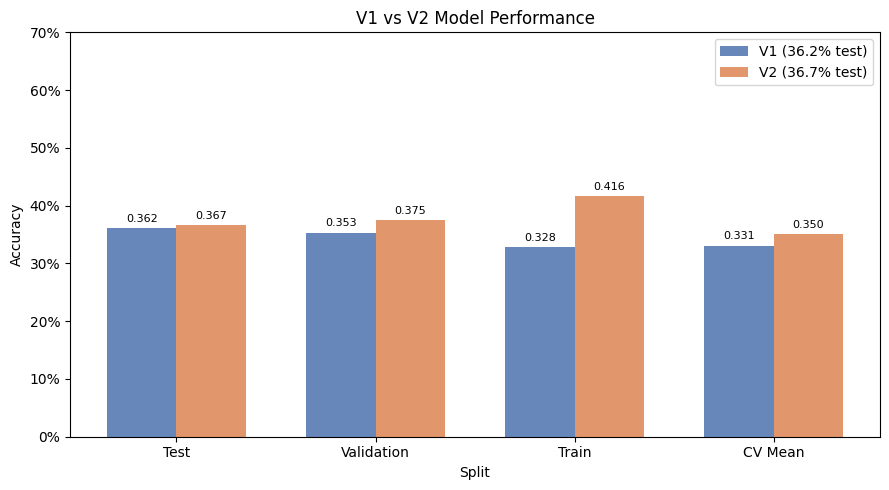

Saved: c:\Users\USER\Documents\AI_CW2\results\v1_v2_comparison.png

V2 Improvements:
  1. Input domain [0,1]               x+x² monotone; removes pre-activation asymmetry
  2. GA eval_epochs 15→25             Root-cause fix: deep networks can show true fitness
  3. 5-gene GA search space           dropout_rate tuned; unstable lr=0.1 removed
  4. Stronger augmentation            Rotation 15°, translate 10%, ColorJitter added
  5. CosineAnnealingLR                Smooth LR decay vs abrupt StepLR halving
  6. Final training 50→100ep          Model was still improving at epoch 50
  7. Kaiming initialisation           Better variance for 3-5 layer deep networks


In [27]:
# ─── V1 vs V2 Grouped Bar Chart ──────────────────────────────────────────────
import matplotlib.patches as mpatches

split_labels = ['Test', 'Validation', 'Train', 'CV Mean']
v1_vals = [
    V1_RESULTS['test_acc'],
    V1_RESULTS['val_acc'],
    V1_RESULTS['train_acc'],
    V1_RESULTS['cv_mean'],
]
v2_vals = [
    V2_RESULTS['test_acc'],
    V2_RESULTS['val_acc'],
    V2_RESULTS['train_acc'],
    V2_RESULTS['cv_mean'],
]

x     = np.arange(len(split_labels))
width = 0.35

fig, ax = plt.subplots(figsize=(9, 5))
bars_v1 = ax.bar(x - width/2, v1_vals, width, label='V1 (36.2% test)', color='#4C72B0', alpha=0.85)
bars_v2 = ax.bar(x + width/2, v2_vals, width, label=f'V2 ({V2_RESULTS["test_acc"]:.1%} test)', color='#DD8452', alpha=0.85)

# Value labels on bars
for bar in bars_v1:
    ax.annotate(f'{bar.get_height():.3f}',
                xy=(bar.get_x() + bar.get_width() / 2, bar.get_height()),
                xytext=(0, 3), textcoords='offset points',
                ha='center', va='bottom', fontsize=8)
for bar in bars_v2:
    ax.annotate(f'{bar.get_height():.3f}',
                xy=(bar.get_x() + bar.get_width() / 2, bar.get_height()),
                xytext=(0, 3), textcoords='offset points',
                ha='center', va='bottom', fontsize=8)

ax.set_xlabel('Split')
ax.set_ylabel('Accuracy')
ax.set_title('V1 vs V2 Model Performance')
ax.set_xticks(x)
ax.set_xticklabels(split_labels)
ax.set_ylim(0, 0.7)
ax.legend()
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.0%}'))
plt.tight_layout()

comparison_path = os.path.join(CONFIG['results_dir'], 'v1_v2_comparison.png')
plt.savefig(comparison_path, dpi=120)
plt.show()
print(f'Saved: {comparison_path}')

# ── Improvement summary ───────────────────────────────────────────────────────
print('\nV2 Improvements:')
improvements = [
    ('1. Input domain [0,1]',        'x+x² monotone; removes pre-activation asymmetry'),
    ('2. GA eval_epochs 15→25',      'Root-cause fix: deep networks can show true fitness'),
    ('3. 5-gene GA search space',    'dropout_rate tuned; unstable lr=0.1 removed'),
    ('4. Stronger augmentation',     'Rotation 15°, translate 10%, ColorJitter added'),
    ('5. CosineAnnealingLR',         'Smooth LR decay vs abrupt StepLR halving'),
    ('6. Final training 50→100ep',   'Model was still improving at epoch 50'),
    ('7. Kaiming initialisation',    'Better variance for 3-5 layer deep networks'),
]
for name, reason in improvements:
    print(f'  {name:<35} {reason}')